In [22]:
import os
from pathlib import Path
from datetime import date
import numpy as np
import xarray as xr
import earthaccess

# ---- 1) Login ----
auth = earthaccess.login()

# ---- 2) Define search parameters ----
tspan = ("2024-09-25", "2024-09-26")  # after June 1, 2024 up to today
bbox  = (-93.588, 24.597, -93.188, 24.997)       # (xmin, ymin, xmax, ymax)
clouds = (0, 100)                                 # optional; you can omit this

# ---- 3) Search ----
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP",
    temporal=tspan,
    bounding_box=bbox,
    # cloud_cover=clouds,  # you can comment this out if you want NO cloud filter
    count=100             # pull up to 100 candidates
)
print(f"Found {len(results)} granules matching filters.")

Found 3 granules matching filters.


In [24]:
import xarray as xr

local_file = earthaccess.download(results[0])[0]

ds_geo = xr.open_dataset(local_file, group="geophysical_data", engine="h5netcdf")

ds_nav = xr.open_dataset(local_file, group="navigation_data", engine="h5netcdf")

print("Geophysical variables:", list(ds_geo.data_vars)[:10])
print("Navigation variables:", list(ds_nav.data_vars)[:10])

QUEUEING TASKS | : 100%|████████████████████████| 1/1 [00:00<00:00, 1811.79it/s]
PROCESSING TASKS | : 100%|████████████████████████| 1/1 [00:02<00:00,  2.92s/it]
COLLECTING RESULTS | : 100%|███████████████████| 1/1 [00:00<00:00, 13315.25it/s]

Geophysical variables: ['Rrs', 'Rrs_unc', 'aot_865', 'angstrom', 'avw', 'nflh', 'l2_flags']
Navigation variables: ['longitude', 'latitude', 'tilt']


In [25]:
import xarray as xr
import earthaccess

paths = earthaccess.download(results[0], "PACE_L2_Data")
local_file = paths[0]   # first file in list

print("Downloaded:", local_file)

try:
    ds = xr.open_dataset(local_file, engine="h5netcdf")
    print(ds)
except Exception:
    # If it's an L2 product, open subgroups
    ds_geo = xr.open_dataset(local_file, group="geophysical_data", engine="h5netcdf")
    ds_nav = xr.open_dataset(local_file, group="navigation_data", engine="h5netcdf")
    print("Geophysical group:\n", ds_geo)
    print("Navigation group:\n", ds_nav)

QUEUEING TASKS | : 100%|████████████████████████| 1/1 [00:00<00:00, 1726.76it/s]
PROCESSING TASKS | : 100%|████████████████████████| 1/1 [00:02<00:00,  2.64s/it]
COLLECTING RESULTS | : 100%|███████████████████| 1/1 [00:00<00:00, 49932.19it/s]

Downloaded: PACE_L2_Data/PACE_OCI.20240925T181238.L2.OC_AOP.V3_0.nc
<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/45)
    title:                             OCI Level-2 Data AOP
    product_name:                      PACE_OCI.20240925T181238.L2.OC_AOP.V3_...
    processing_version:                3.0
    history:                           l2gen par=/data15/sdpsoper/vdc/vpu14/w...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                -69.00336
    geospatial_lon_min:                -101.692474
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     0.9946473240852356


/var/folders/54/5kc2y0693j37p_j3_04pyxkc0000gn/T/ipykernel_12767/2449724483.py:51: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.legend(); plt.tight_layout(); plt.show()


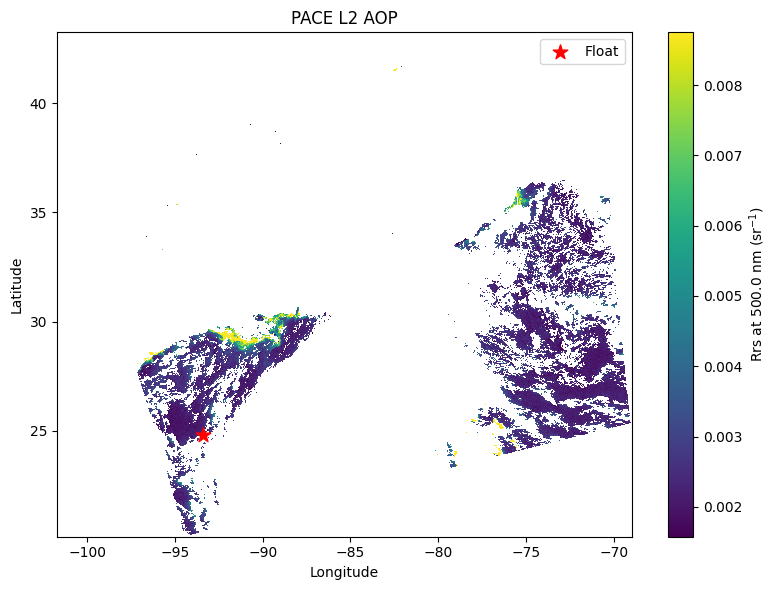

Used band index 76 at 500.0 nm (target 500 nm)


In [29]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

target_nm = 500                      

R = ds_geo["Rrs"]
band_dim = R.dims[-1]                  
wl = ds_geo.get("wavelength", None)
if wl is None:
    try:
        sbp = xr.open_dataset(local_file, group="sensor_band_parameters", engine="h5netcdf")
        wl = sbp["wavelength"]; sbp.close()
    except Exception:
        wl = None

if wl is None:
    raise ValueError("No wavelength vector found in this file.")
wl = np.asarray(wl.values).astype(float)

i = int(np.nanargmin(np.abs(wl - target_nm)))
rrs = R.isel({band_dim: i}).values
lat = ds_nav["latitude"].values
lon = ds_nav["longitude"].values

if rrs.shape != lat.shape:
    if rrs.T.shape == lat.shape:
        rrs = rrs.T
    else:
        raise ValueError(f"Shape mismatch: Rrs {rrs.shape} vs lat {lat.shape}")

q2, q98 = np.nanpercentile(rrs[np.isfinite(rrs)], [2, 98]) if np.isfinite(rrs).any() else (0, 0.02)
vmin, vmax = (max(0, q2), q98) if np.isfinite(q2) and np.isfinite(q98) and q2 < q98 else (0, 0.02)

float_lat, float_lon = 24.797, -93.388
float_lon_plot = float_lon % 360 if (np.nanmin(lon) >= 0 and np.nanmax(lon) > 180) else float_lon

plt.figure(figsize=(8,6))
im = plt.pcolormesh(lon, lat, rrs, cmap="viridis", vmin=vmin, vmax=vmax)
plt.colorbar(im, label=f"Rrs at {wl[i]:.1f} nm (sr$^{{-1}}$)")
plt.scatter(float_lon_plot, float_lat, c="red", marker="*", s=120, label="Float")
plt.title(ds_geo.attrs.get("product_name", "PACE L2 AOP"))
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.legend(); plt.tight_layout(); plt.show()

print(f"Used band index {i} at {wl[i]:.1f} nm (target {target_nm} nm)")

/var/folders/54/5kc2y0693j37p_j3_04pyxkc0000gn/T/ipykernel_12767/1380582076.py:35: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


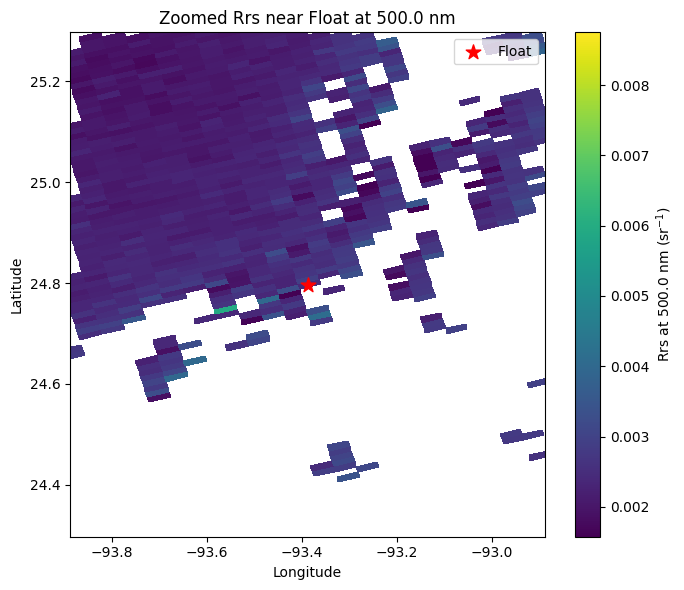

In [30]:
import matplotlib.pyplot as plt
import numpy as np

float_lat, float_lon = 24.797, -93.388

pad = 0.5  

lat_min, lat_max = float_lat - pad, float_lat + pad
lon_min, lon_max = float_lon - pad, float_lon + pad

if np.nanmin(lon) >= 0 and np.nanmax(lon) > 180:
    float_lon_plot = float_lon % 360
    lon_min, lon_max = lon_min % 360, lon_max % 360
else:
    float_lon_plot = float_lon

mask = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)

rrs_zoom = np.where(mask, rrs, np.nan)

plt.figure(figsize=(7,6))
im = plt.pcolormesh(lon, lat, rrs_zoom, cmap="viridis", vmin=vmin, vmax=vmax)
plt.colorbar(im, label=f"Rrs at {wl[i]:.1f} nm (sr$^{{-1}}$)")
plt.scatter(float_lon_plot, float_lat, c="red", marker="*", s=120, label="Float")
plt.legend()
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title(f"Zoomed Rrs near Float at {wl[i]:.1f} nm")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.tight_layout()
plt.show()

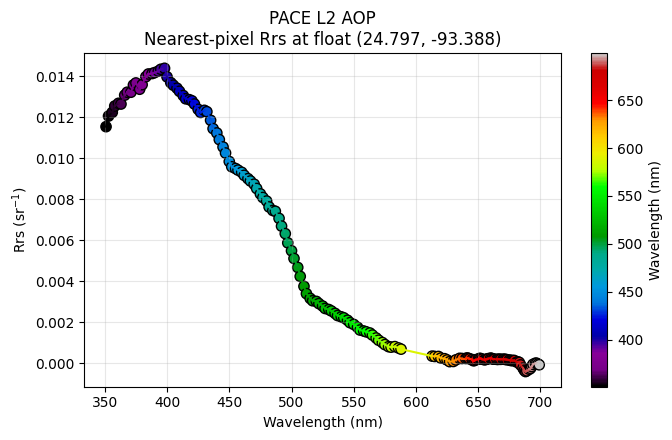

Nearest pixel lat/lon: 24.79805, -93.38410


In [38]:
import numpy as np
import xarray as xr
import h5py
import matplotlib.pyplot as plt

R = ds_geo["Rrs"]
n_spec = R.shape[-1]

def looks_like_wavelength(vec):
    vec = np.asarray(vec, dtype=float).ravel()
    if vec.size != n_spec: 
        return False
    if not np.isfinite(vec).all(): 
        return False
    if not np.all(np.diff(vec) >= 0):  # non-decreasing
        return False
    lo, hi = np.nanmin(vec), np.nanmax(vec)
    return (300 <= lo <= 450) and (600 <= hi <= 900)

def find_wavelength_vector(local_file):
    # 1) sensor_band_parameters: any 1-D float var len==n_spec
    try:
        sbp = xr.open_dataset(local_file, group="sensor_band_parameters", engine="h5netcdf")
        for name, da in sbp.data_vars.items():
            if da.ndim == 1 and da.sizes[list(da.sizes.keys())[0]] == n_spec and np.issubdtype(da.dtype, np.floating):
                arr = np.asarray(da.values, dtype=float)
                if looks_like_wavelength(arr):
                    sbp.close()
                    return arr
        sbp.close()
    except Exception:
        pass

    # 2) attributes on geophysical_data or Rrs itself
    for src in (ds_geo.attrs, getattr(ds_geo["Rrs"], "attrs", {})):
        for k, v in src.items():
            try:
                arr = np.asarray(v, dtype=float).ravel()
                if looks_like_wavelength(arr):
                    return arr
            except Exception:
                continue

    # 3) brute-force search across all groups with h5py
    with h5py.File(local_file, "r") as f:
        found = []
        def visit(name, obj):
            if isinstance(obj, h5py.Dataset):
                try:
                    if obj.ndim == 1 and obj.shape[0] == n_spec and np.issubdtype(obj.dtype, np.number):
                        arr = obj[...].astype(float)
                        if looks_like_wavelength(arr):
                            found.append((name, arr))
                except Exception:
                    pass
        f.visititems(visit)
        if found:
            # prefer names containing "wave"
            found.sort(key=lambda x: ("wave" not in x[0].lower(), x[0]))
            return found[0][1]

    return None

wl_subset = find_wavelength_vector(local_file)
if wl_subset is None:
    raise ValueError("Couldn't find a 172-band wavelength vector in this file. "
                     "If you print the contents of sensor_band_parameters, I can key the exact field names.")

# ---- nearest pixel to your float ----
float_lat, float_lon = 24.797, -93.388
lat = ds_nav["latitude"].values
lon = ds_nav["longitude"].values
flon = float_lon % 360 if (np.nanmin(lon) >= 0 and np.nanmax(lon) > 180) else float_lon
k = np.nanargmin((lat - float_lat)**2 + (lon - flon)**2)
irow, icol = np.unravel_index(k, lat.shape)

spec = R.isel({R.dims[0]: irow, R.dims[1]: icol}).values
spec = np.squeeze(spec)
if spec.size != wl_subset.size:
    # handle uncommon dim order
    spec = R.isel({R.dims[-1]: slice(None), R.dims[0]: irow, R.dims[1]: icol}).values
    spec = np.squeeze(spec)
    if spec.size != wl_subset.size:
        raise ValueError(f"Rrs band count {spec.size} still != wavelength count {wl_subset.size}")

# limit to 350–700 nm
mask = (wl_subset >= 350) & (wl_subset <= 700) & np.isfinite(spec)
wl = wl_subset[mask]
yy = spec[mask]

# plot with spectral colors
plt.figure(figsize=(7,4.5))
sc = plt.scatter(wl, yy, c=wl, cmap="nipy_spectral", s=55, edgecolor="k")
for i in range(len(wl)-1):
    c = plt.cm.nipy_spectral((wl[i]-wl.min())/(wl.max()-wl.min()))
    plt.plot(wl[i:i+2], yy[i:i+2], color=c)
plt.colorbar(sc, label="Wavelength (nm)")
plt.xlabel("Wavelength (nm)"); plt.ylabel("Rrs (sr$^{-1}$)")
plt.title(f"{ds_geo.attrs.get('product_name','PACE L2 AOP')}\nNearest-pixel Rrs at float ({float_lat:.3f}, {float_lon:.3f})")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"Nearest pixel lat/lon: {lat[irow,icol]:.5f}, {lon[irow,icol]:.5f}")

In [52]:
import xarray as xr

ds_geo = xr.open_dataset(local_file, group="geophysical_data", engine="h5netcdf")
ds_nav = xr.open_dataset(local_file, group="navigation_data", engine="h5netcdf")
ds_sbp = xr.open_dataset(local_file, group="sensor_band_parameters", engine="h5netcdf")

print("Geophysical variables:", list(ds_geo.variables))
print("Navigation variables:", list(ds_nav.variables))
print("Sensor band parameters:", list(ds_sbp.variables))

ds_geo.close()
ds_nav.close()
ds_sbp.close()


Geophysical variables: ['Rrs', 'Rrs_unc', 'aot_865', 'angstrom', 'avw', 'nflh', 'l2_flags']
Navigation variables: ['longitude', 'latitude', 'tilt']
Sensor band parameters: ['wavelength', 'wavelength_3d', 'vcal_gain', 'vcal_offset', 'F0', 'aw', 'bbw', 'k_oz', 'k_no2', 'Tau_r']
